# House Price Prediction (Working)

## Step 1: Import Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Tabulate for fancy outputs
from tabulate import tabulate

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Sklearn - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Sklearn - Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(tabulate([["All Libraries Imported Successfully!"]], tablefmt="fancy_grid"))

╒══════════════════════════════════════╕
│ All Libraries Imported Successfully! │
╘══════════════════════════════════════╛


## Step 2: Load Dataset

In [2]:
# Load Dataset
df = pd.read_csv('train.csv')

# Dataset Overview Table
overview = [
    ["Total Rows",        df.shape[0]],
    ["Total Columns",     df.shape[1]],
    ["Numerical Features", df.select_dtypes(include=np.number).shape[1]],
    ["Categorical Features", df.select_dtypes(include='object').shape[1]],
    ["Missing Values",    df.isnull().sum().sum()],
    ["Duplicate Rows",    df.duplicated().sum()]
]

print(tabulate(overview,
               headers=["Dataset Info", "Value"],
               tablefmt="fancy_grid"))

╒══════════════════════╤═════════╕
│ Dataset Info         │   Value │
╞══════════════════════╪═════════╡
│ Total Rows           │    1460 │
├──────────────────────┼─────────┤
│ Total Columns        │      81 │
├──────────────────────┼─────────┤
│ Numerical Features   │      38 │
├──────────────────────┼─────────┤
│ Categorical Features │      43 │
├──────────────────────┼─────────┤
│ Missing Values       │    7829 │
├──────────────────────┼─────────┤
│ Duplicate Rows       │       0 │
╘══════════════════════╧═════════╛


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Target Variable Stats
target_stats = [
    ["Min Price",    f"${df['SalePrice'].min():,.0f}"],
    ["Max Price",    f"${df['SalePrice'].max():,.0f}"],
    ["Mean Price",   f"${df['SalePrice'].mean():,.0f}"],
    ["Median Price", f"${df['SalePrice'].median():,.0f}"],
    ["Std Dev",      f"${df['SalePrice'].std():,.0f}"],
    ["Skewness",     f"{df['SalePrice'].skew():.4f}"]
]

print(tabulate(target_stats,
               headers=["SalePrice Statistics", "Value"],
               tablefmt="fancy_grid"))

╒════════════════════════╤══════════╕
│ SalePrice Statistics   │ Value    │
╞════════════════════════╪══════════╡
│ Min Price              │ $34,900  │
├────────────────────────┼──────────┤
│ Max Price              │ $755,000 │
├────────────────────────┼──────────┤
│ Mean Price             │ $180,921 │
├────────────────────────┼──────────┤
│ Median Price           │ $163,000 │
├────────────────────────┼──────────┤
│ Std Dev                │ $79,443  │
├────────────────────────┼──────────┤
│ Skewness               │ 1.8829   │
╘════════════════════════╧══════════╛


In [4]:
# Top 10 Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(10)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = list(zip(missing.index, missing.values, missing_pct.values))

print(tabulate(missing_table,
               headers=["Feature", "Missing Count", "Missing %"],
               tablefmt="fancy_grid"))

╒══════════════╤═════════════════╤═════════════╕
│ Feature      │   Missing Count │   Missing % │
╞══════════════╪═════════════════╪═════════════╡
│ PoolQC       │            1453 │       99.52 │
├──────────────┼─────────────────┼─────────────┤
│ MiscFeature  │            1406 │       96.3  │
├──────────────┼─────────────────┼─────────────┤
│ Alley        │            1369 │       93.77 │
├──────────────┼─────────────────┼─────────────┤
│ Fence        │            1179 │       80.75 │
├──────────────┼─────────────────┼─────────────┤
│ MasVnrType   │             872 │       59.73 │
├──────────────┼─────────────────┼─────────────┤
│ FireplaceQu  │             690 │       47.26 │
├──────────────┼─────────────────┼─────────────┤
│ LotFrontage  │             259 │       17.74 │
├──────────────┼─────────────────┼─────────────┤
│ GarageType   │              81 │        5.55 │
├──────────────┼─────────────────┼─────────────┤
│ GarageYrBlt  │              81 │        5.55 │
├──────────────┼────

In [5]:
# Correlation with SalePrice - Top 10 Features
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
top_corr = corr.head(10)

corr_table = [(feat, f"{val:.4f}") for feat, val in top_corr.items()]

print(tabulate(corr_table,
               headers=["Feature", "Correlation with SalePrice"],
               tablefmt="fancy_grid"))

╒══════════════╤══════════════════════════════╕
│ Feature      │   Correlation with SalePrice │
╞══════════════╪══════════════════════════════╡
│ OverallQual  │                       0.791  │
├──────────────┼──────────────────────────────┤
│ GrLivArea    │                       0.7086 │
├──────────────┼──────────────────────────────┤
│ GarageCars   │                       0.6404 │
├──────────────┼──────────────────────────────┤
│ GarageArea   │                       0.6234 │
├──────────────┼──────────────────────────────┤
│ TotalBsmtSF  │                       0.6136 │
├──────────────┼──────────────────────────────┤
│ 1stFlrSF     │                       0.6059 │
├──────────────┼──────────────────────────────┤
│ FullBath     │                       0.5607 │
├──────────────┼──────────────────────────────┤
│ TotRmsAbvGrd │                       0.5337 │
├──────────────┼──────────────────────────────┤
│ YearBuilt    │                       0.5229 │
├──────────────┼────────────────────────

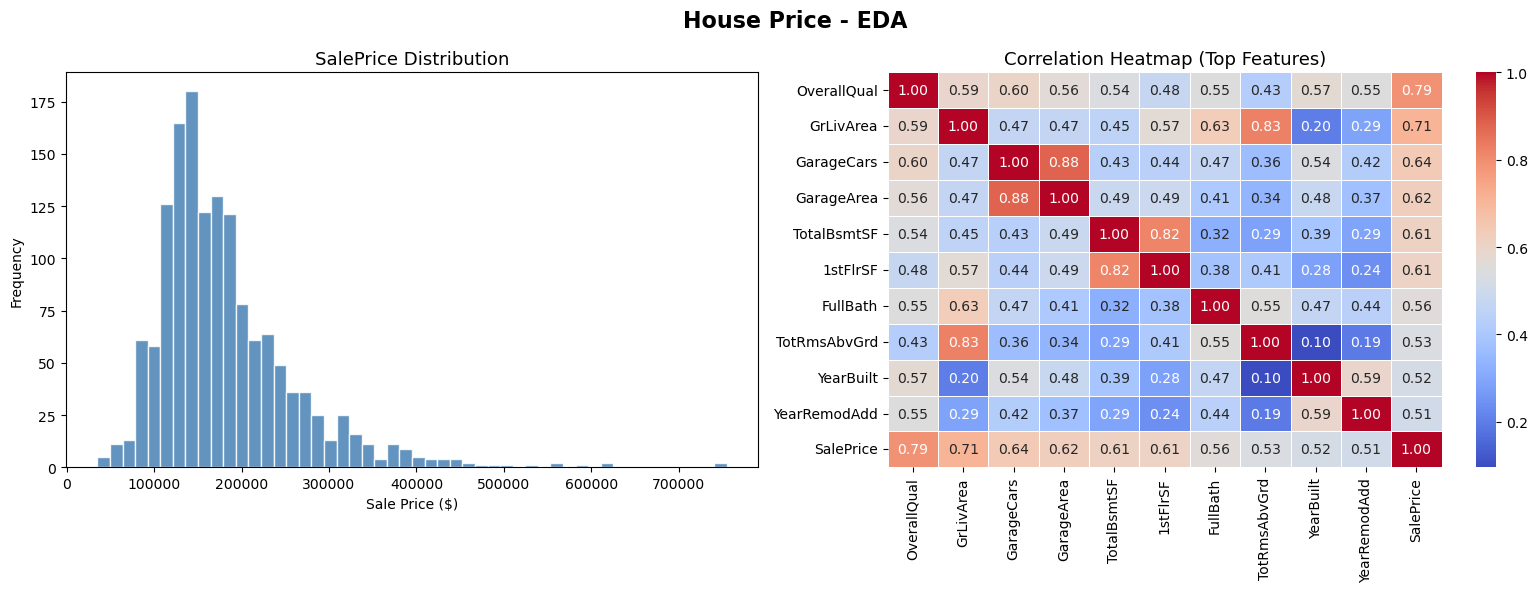

In [6]:
# Visualization - SalePrice Distribution & Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('House Price - EDA', fontsize=16, fontweight='bold')

# Plot 1: SalePrice Distribution
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('SalePrice Distribution', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

# Plot 2: Heatmap of Top Correlated Features
top_features = top_corr.index.tolist() + ['SalePrice']
sns.heatmap(num_df[top_features].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlation Heatmap (Top Features)', fontsize=13)

plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [7]:
# Drop ID column
df.drop(columns=['Id'], inplace=True)

# Separate target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Encode Categorical Features
cat_cols = X.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

# Impute Missing Values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

split_info = [
    ["Training Samples",   X_train.shape[0]],
    ["Testing Samples",    X_test.shape[0]],
    ["Total Features",     X_train.shape[1]],
    ["Categorical Encoded", len(cat_cols)],
    ["Train/Test Ratio",   "80% / 20%"]
]

print(tabulate(split_info,
               headers=["Preprocessing Summary", "Value"],
               tablefmt="fancy_grid"))

╒═════════════════════════╤═══════════╕
│ Preprocessing Summary   │ Value     │
╞═════════════════════════╪═══════════╡
│ Training Samples        │ 1168      │
├─────────────────────────┼───────────┤
│ Testing Samples         │ 292       │
├─────────────────────────┼───────────┤
│ Total Features          │ 79        │
├─────────────────────────┼───────────┤
│ Categorical Encoded     │ 43        │
├─────────────────────────┼───────────┤
│ Train/Test Ratio        │ 80% / 20% │
╘═════════════════════════╧═══════════╛


## Step 5: Model Training & Evaluation
> **Suggested Models:** Linear Regression (baseline), Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting (best)

In [8]:
# Define Models
models = {
    "Linear Regression":    LinearRegression(),
    "Ridge Regression":     Ridge(alpha=1.0),
    "Lasso Regression":     Lasso(alpha=1.0),
    "Decision Tree":        DecisionTreeRegressor(random_state=42),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae   = mean_absolute_error(y_test, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
    r2    = r2_score(y_test, y_pred)
    cv    = cross_val_score(model, X_scaled, y, cv=5, scoring='r2').mean()

    results.append([name,
                    f"${mae:,.0f}",
                    f"${rmse:,.0f}",
                    f"{r2:.4f}",
                    f"{cv:.4f}"])

print(tabulate(results,
               headers=["Model", "MAE", "RMSE", "R² Score", "CV R² (5-fold)"],
               tablefmt="fancy_grid"))

╒═══════════════════╤═════════╤═════════╤════════════╤══════════════════╕
│ Model             │ MAE     │ RMSE    │   R² Score │   CV R² (5-fold) │
╞═══════════════════╪═════════╪═════════╪════════════╪══════════════════╡
│ Linear Regression │ $21,563 │ $34,557 │     0.8443 │           0.7999 │
├───────────────────┼─────────┼─────────┼────────────┼──────────────────┤
│ Ridge Regression  │ $21,550 │ $34,544 │     0.8444 │           0.8004 │
├───────────────────┼─────────┼─────────┼────────────┼──────────────────┤
│ Lasso Regression  │ $21,561 │ $34,556 │     0.8443 │           0.8    │
├───────────────────┼─────────┼─────────┼────────────┼──────────────────┤
│ Decision Tree     │ $27,788 │ $42,102 │     0.7689 │           0.7271 │
├───────────────────┼─────────┼─────────┼────────────┼──────────────────┤
│ Random Forest     │ $17,706 │ $28,544 │     0.8938 │           0.8605 │
├───────────────────┼─────────┼─────────┼────────────┼──────────────────┤
│ Gradient Boosting │ $17,105 │ $28,15

## Step 6: Best Model - Gradient Boosting (Detailed Analysis)

In [9]:
# Best Model: Gradient Boosting
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Residuals
residuals = y_test.values - y_pred_best

# Metrics
mae  = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2   = r2_score(y_test, y_pred_best)

best_metrics = [
    ["Model",             "Gradient Boosting Regressor"],
    ["MAE",               f"${mae:,.2f}"],
    ["RMSE",              f"${rmse:,.2f}"],
    ["R² Score",          f"{r2:.4f}"],
    ["Accuracy",          f"{r2*100:.2f}%"],
    ["Mean Residual",     f"${residuals.mean():,.2f}"],
    ["Residual Std Dev",  f"${residuals.std():,.2f}"]
]

print(tabulate(best_metrics,
               headers=["Best Model Metrics", "Result"],
               tablefmt="fancy_grid"))

╒══════════════════════╤═════════════════════════════╕
│ Best Model Metrics   │ Result                      │
╞══════════════════════╪═════════════════════════════╡
│ Model                │ Gradient Boosting Regressor │
├──────────────────────┼─────────────────────────────┤
│ MAE                  │ $17,105.39                  │
├──────────────────────┼─────────────────────────────┤
│ RMSE                 │ $28,157.83                  │
├──────────────────────┼─────────────────────────────┤
│ R² Score             │ 0.8966                      │
├──────────────────────┼─────────────────────────────┤
│ Accuracy             │ 89.66%                      │
├──────────────────────┼─────────────────────────────┤
│ Mean Residual        │ $562.68                     │
├──────────────────────┼─────────────────────────────┤
│ Residual Std Dev     │ $28,152.21                  │
╘══════════════════════╧═════════════════════════════╛


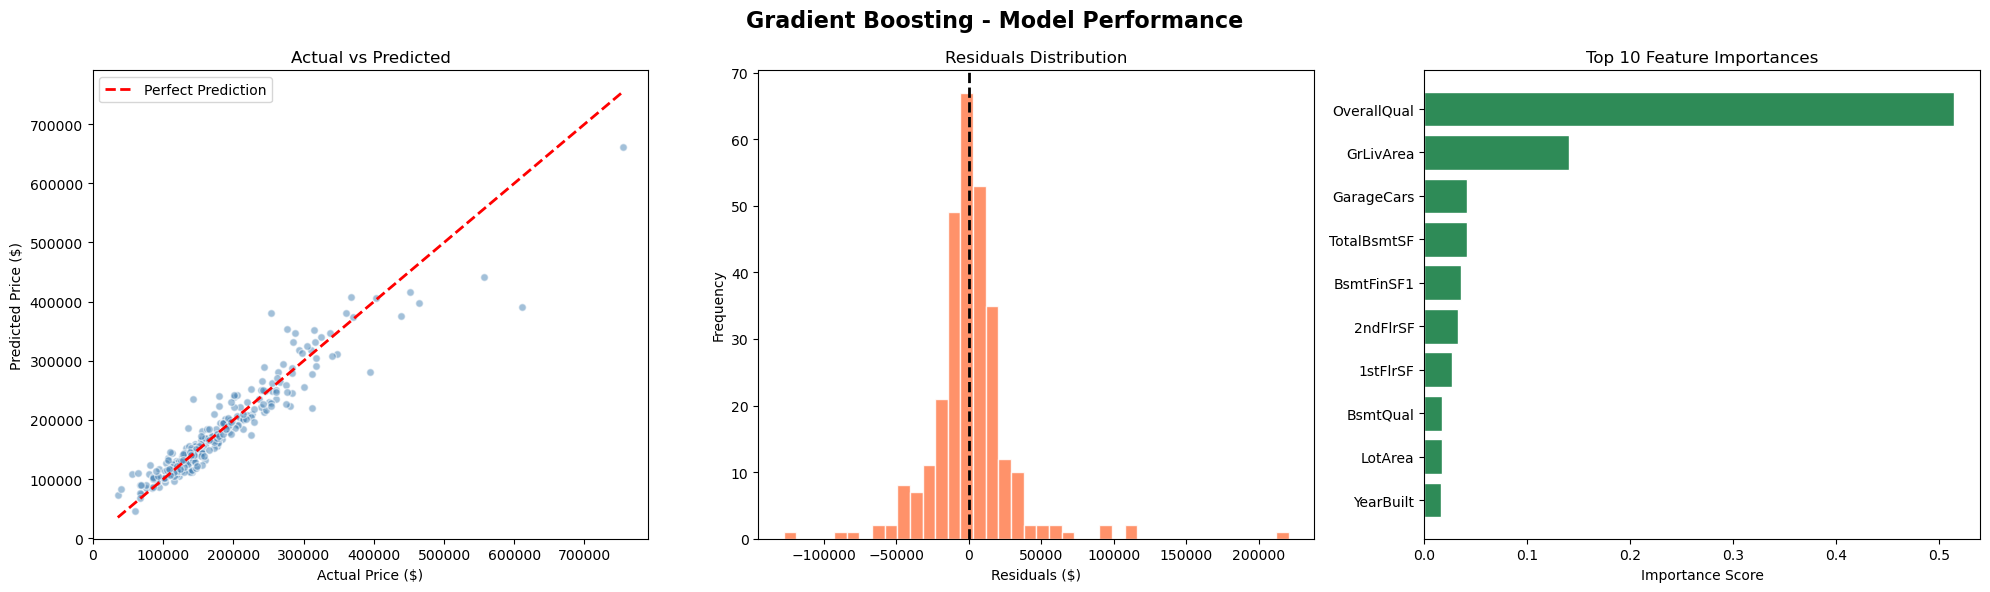

In [10]:
# Visualizations for Best Model
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Gradient Boosting - Model Performance', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolors='white', s=30)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Plot 2: Residuals Distribution
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

# Plot 3: Top 10 Feature Importances
feat_imp = pd.Series(best_model.feature_importances_,
                     index=X_imputed.columns).sort_values(ascending=False).head(10)
axes[2].barh(feat_imp.index[::-1], feat_imp.values[::-1], color='seagreen', edgecolor='white')
axes[2].set_xlabel('Importance Score')
axes[2].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

## Step 7: Top Features & Importance

In [11]:
# Feature Importance Table
feat_importance = pd.Series(
    best_model.feature_importances_,
    index=X_imputed.columns
).sort_values(ascending=False).head(15)

feat_table = [(i+1, feat, f"{val:.4f}", f"{val*100:.2f}%")
              for i, (feat, val) in enumerate(feat_importance.items())]

print(tabulate(feat_table,
               headers=["Rank", "Feature", "Importance Score", "Contribution %"],
               tablefmt="fancy_grid"))

╒════════╤══════════════╤════════════════════╤══════════════════╕
│   Rank │ Feature      │   Importance Score │ Contribution %   │
╞════════╪══════════════╪════════════════════╪══════════════════╡
│      1 │ OverallQual  │             0.5136 │ 51.36%           │
├────────┼──────────────┼────────────────────┼──────────────────┤
│      2 │ GrLivArea    │             0.1406 │ 14.06%           │
├────────┼──────────────┼────────────────────┼──────────────────┤
│      3 │ GarageCars   │             0.0418 │ 4.18%            │
├────────┼──────────────┼────────────────────┼──────────────────┤
│      4 │ TotalBsmtSF  │             0.0415 │ 4.15%            │
├────────┼──────────────┼────────────────────┼──────────────────┤
│      5 │ BsmtFinSF1   │             0.0356 │ 3.56%            │
├────────┼──────────────┼────────────────────┼──────────────────┤
│      6 │ 2ndFlrSF     │             0.0324 │ 3.24%            │
├────────┼──────────────┼────────────────────┼──────────────────┤
│      7 │

## Step 8: Sample Predictions

In [12]:
# Sample Predictions Comparison
sample_df = pd.DataFrame({
    'Actual Price':    y_test.values[:10],
    'Predicted Price': y_pred_best[:10].round(0)
})
sample_df['Difference ($)'] = (sample_df['Predicted Price'] - sample_df['Actual Price']).round(0)
sample_df['Error %'] = ((abs(sample_df['Difference ($)']) / sample_df['Actual Price']) * 100).round(2)

pred_table = [
    [i+1,
     f"${row['Actual Price']:,.0f}",
     f"${row['Predicted Price']:,.0f}",
     f"${row['Difference ($)']:,.0f}",
     f"{row['Error %']:.2f}%"]
    for i, (_, row) in enumerate(sample_df.iterrows())
]

print(tabulate(pred_table,
               headers=["#", "Actual Price", "Predicted Price", "Difference", "Error %"],
               tablefmt="fancy_grid"))

╒═════╤════════════════╤═══════════════════╤══════════════╤═══════════╕
│   # │ Actual Price   │ Predicted Price   │ Difference   │ Error %   │
╞═════╪════════════════╪═══════════════════╪══════════════╪═══════════╡
│   1 │ $154,500       │ $141,825          │ $-12,675     │ 8.20%     │
├─────┼────────────────┼───────────────────┼──────────────┼───────────┤
│   2 │ $325,000       │ $340,852          │ $15,852      │ 4.88%     │
├─────┼────────────────┼───────────────────┼──────────────┼───────────┤
│   3 │ $115,000       │ $117,315          │ $2,315       │ 2.01%     │
├─────┼────────────────┼───────────────────┼──────────────┼───────────┤
│   4 │ $159,000       │ $157,198          │ $-1,802      │ 1.13%     │
├─────┼────────────────┼───────────────────┼──────────────┼───────────┤
│   5 │ $315,500       │ $331,802          │ $16,302      │ 5.17%     │
├─────┼────────────────┼───────────────────┼──────────────┼───────────┤
│   6 │ $75,500        │ $84,847           │ $9,347       │ 12.3

## Step 9: Final Model Comparison Summary

In [13]:
# Final Summary Table
summary = [
    ["Project",          "House Price Prediction"],
    ["Dataset",          "Kaggle - House Prices (Ames, Iowa)"],
    ["Total Records",    "1,460 training samples"],
    ["Features Used",    f"{X_train.shape[1]}"],
    ["Best Model",       "Gradient Boosting Regressor"],
    ["Best R² Score",    f"{r2_score(y_test, y_pred_best):.4f}"],
    ["Best MAE",         f"${mean_absolute_error(y_test, y_pred_best):,.2f}"],
    ["Best RMSE",        f"${np.sqrt(mean_squared_error(y_test, y_pred_best)):,.2f}"],
    ["Train/Test Split", "80% / 20%"],
    ["Cross-Validation", "5-Fold CV"]
]

print(tabulate(summary,
               headers=["Final Project Summary", "Details"],
               tablefmt="fancy_grid"))

print("\nHouse Price Prediction Project Complete!")

╒═════════════════════════╤════════════════════════════════════╕
│ Final Project Summary   │ Details                            │
╞═════════════════════════╪════════════════════════════════════╡
│ Project                 │ House Price Prediction             │
├─────────────────────────┼────────────────────────────────────┤
│ Dataset                 │ Kaggle - House Prices (Ames, Iowa) │
├─────────────────────────┼────────────────────────────────────┤
│ Total Records           │ 1,460 training samples             │
├─────────────────────────┼────────────────────────────────────┤
│ Features Used           │ 79                                 │
├─────────────────────────┼────────────────────────────────────┤
│ Best Model              │ Gradient Boosting Regressor        │
├─────────────────────────┼────────────────────────────────────┤
│ Best R² Score           │ 0.8966                             │
├─────────────────────────┼────────────────────────────────────┤
│ Best MAE               